In [7]:
!pip install kagglehub tensorflow matplotlib seaborn scikit-learn

In [8]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
path = kagglehub.dataset_download(
    "vipoooool/new-plant-diseases-dataset"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Dataset path: /kaggle/input/new-plant-diseases-dataset


In [10]:
data_dir = os.path.join(path, "New Plant Diseases Dataset(Augmented)")
print(os.listdir(data_dir))

['New Plant Diseases Dataset(Augmented)']


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [13]:
train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 70294 images belonging to 1 classes.


In [14]:
valid_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 17573 images belonging to 1 classes.


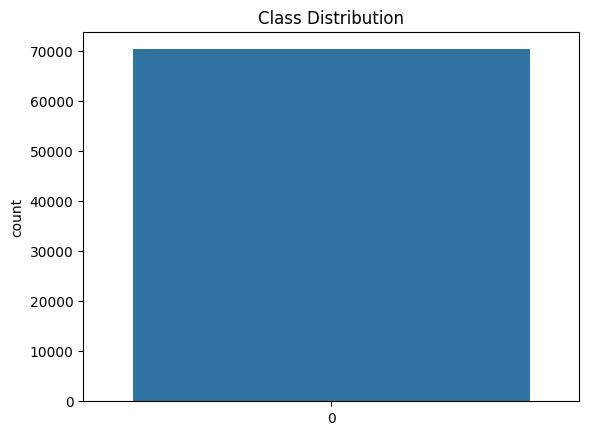

In [15]:
sns.countplot(x=train_data.classes)
plt.title("Class Distribution")
plt.show()

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,244,929 (84.86 MB)

 Trainable params: 22,244,929 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=valid_data
)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1108s 504ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1093s 498ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1083s 493ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1081s 492ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1072s 488ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


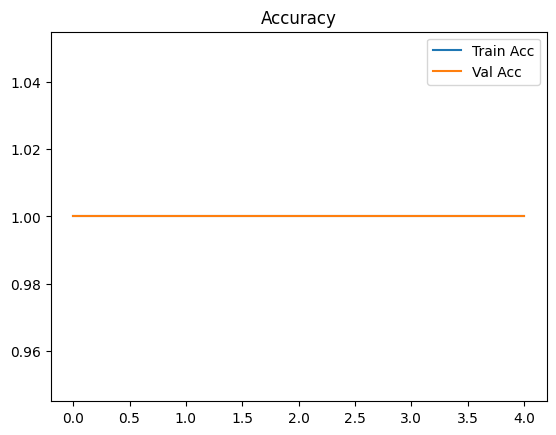

In [20]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

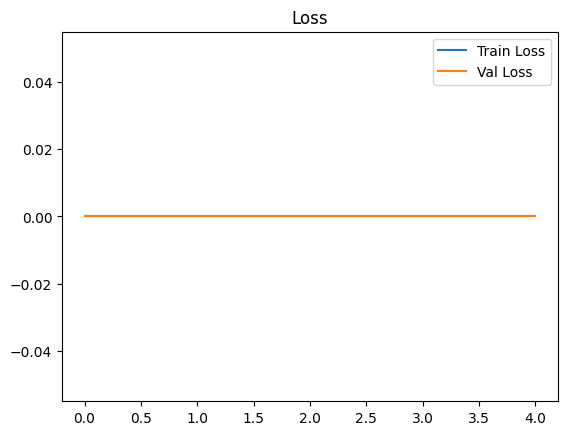

In [21]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [22]:
preds = model.predict(valid_data)
preds = np.argmax(preds, axis=1)

true_labels = valid_data.classes

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


550/550 ━━━━━━━━━━━━━━━━━━━━ 206s 373ms/step


In [23]:
print(classification_report(true_labels, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17573

    accuracy                           1.00     17573
   macro avg       1.00      1.00      1.00     17573
weighted avg       1.00      1.00      1.00     17573



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


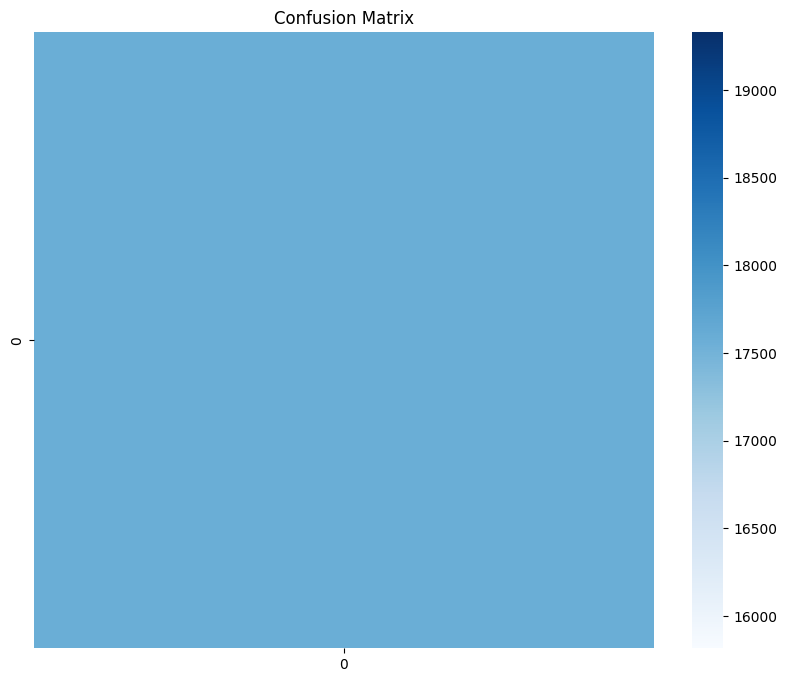

In [24]:
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

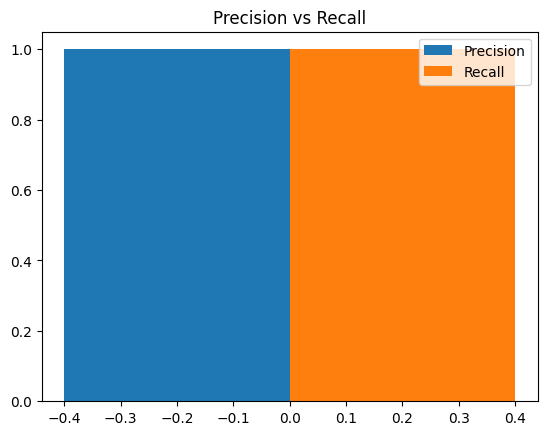

In [25]:
precision = []
recall = []

report = classification_report(true_labels, preds, output_dict=True)

for key in report:
    if key not in ['accuracy','macro avg','weighted avg']:
        precision.append(report[key]['precision'])
        recall.append(report[key]['recall'])

x = np.arange(len(precision))

plt.bar(x-0.2, precision, 0.4, label='Precision')
plt.bar(x+0.2, recall, 0.4, label='Recall')

plt.legend()
plt.title("Precision vs Recall")
plt.show()

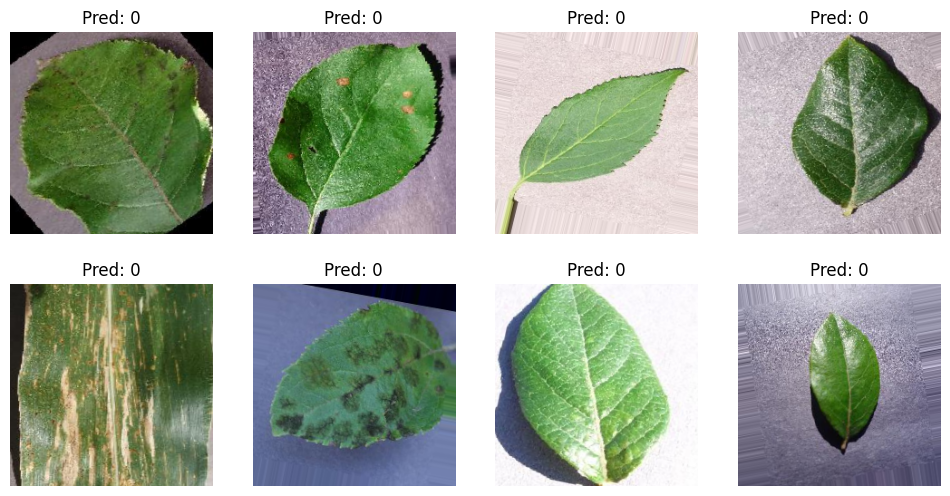

In [26]:
images, labels = next(valid_data)

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title(f"Pred: {preds[i]}")
    plt.axis("off")

plt.show()